In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [16]:
IMG_SIZE = (224, 224)
BATCH = 32
PATH = os.path.expanduser("~/Personal/Facultate/an4/machine learning/CampusPlannerInfo/kaggle_FloorPlan_AsutoshPrad_notebook/datasets/kaggle_FloorPlan_AsutoshPrad_notebook")  # Update path

In [17]:
print("Folders in dataset:", os.listdir(PATH))
for folder in os.listdir(PATH):
    print(f"{folder}: {len(os.listdir(os.path.join(PATH, folder)))} images")

Folders in dataset: ['X', 'Y']
X: 121 images
Y: 121 images


In [18]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 242 files belonging to 2 classes.
Using 194 files for training.
Found 242 files belonging to 2 classes.
Using 48 files for validation.
Classes: ['X', 'Y']


In [19]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,),
    include_top=False,
    weights=None  # Use 'imagenet' if you want pretrained
)
base.trainable = False

inputs = layers.Input(shape=IMG_SIZE+(3,))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = models.Model(inputs, outputs)

In [20]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(train_ds, validation_data=val_ds, epochs=5)

Epoch 1/5


2025-12-02 14:24:04.292911: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.292943: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.292955: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.292973: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.376065: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.379323: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.395087: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.430775: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:04.470684: W tensorflow/core/lib/png/png_io.cc:95] PNG 

1/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.5312 - loss: 0.6931

2025-12-02 14:24:05.450598: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.453547: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.519562: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.523795: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.527540: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.576297: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.600933: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.623420: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:05.804496: W tensorflow/core/lib/png/png_io.cc:95] PNG 

2/7 ━━━━━━━━━━━━━━━━━━━━ 2s 578ms/step - accuracy: 0.5391 - loss: 0.6931

...

3/7 ━━━━━━━━━━━━━━━━━━━━ 2s 585ms/step - accuracy: 0.5486 - loss: 0.6923

2025-12-02 14:24:25.748839: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile


6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.5281 - loss: 0.6927

2025-12-02 14:24:26.586532: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.586560: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.586574: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.586596: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.586606: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.586932: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.666233: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.667111: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:24:26.684887: W tensorflow/core/lib/png/png_io.cc:95] PNG 

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 538ms/step - accuracy: 0.5052 - loss: 0.6931 - val_accuracy: 0.4792 - val_loss: 0.6936


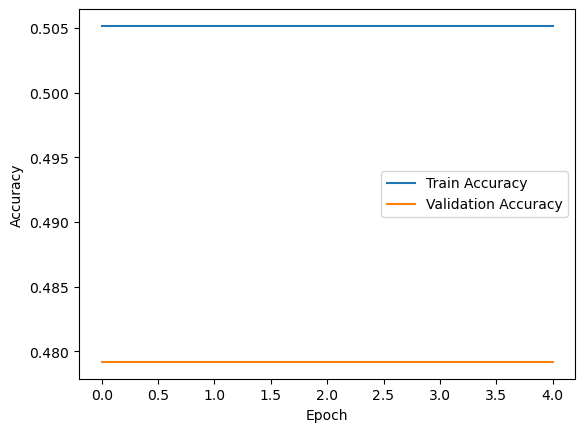

In [22]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

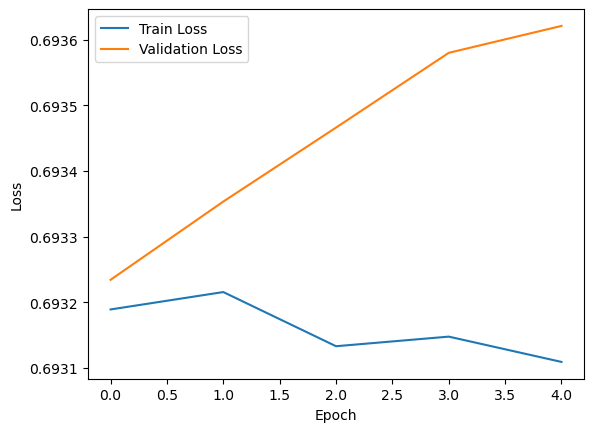

In [23]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

2025-12-02 14:28:34.351791: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.351844: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.351871: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.352325: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.400607: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.475515: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.514632: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.518292: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
2025-12-02 14:28:34.556976: W tensorflow/core/lib/png/png_io.cc:95] PNG 

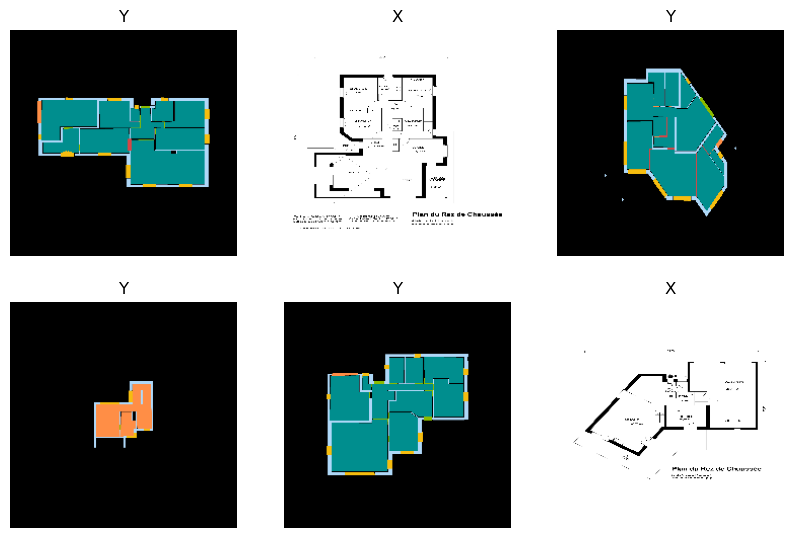

In [24]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(6):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")